# GeoClip Evaluation — Baseline vs Fine-Tuned

Compares the original pretrained GeoCLIP against the Italy fine-tuned model.

## What this notebook does
1. Loads the cleaned dataset from Drive and creates a held-out **test split**
2. Defines **sanity-check** images (famous Italian landmarks with known GPS)
3. Loads **Baseline GeoCLIP** (no fine-tuning)
4. Loads **Fine-Tuned GeoClipItaly** from a checkpoint
5. Runs inference with both models on the same test images
6. Produces **comparison charts**: error histogram, accuracy @ threshold, confusion matrix
7. Shows predictions on an **interactive map**
8. Runs **MC Dropout heatmap** for the fine-tuned model on a single image

## Run order (all cells, top to bottom)

| # | Cell | Notes |
|---|------|-------|
| 1 | Install | Every session |
| 2 | Config | Edit paths here if needed |
| 3 | Mount Drive | Every session |
| 4 | Load Dataset & Split | Creates test_df |
| 5 | Sanity Images | Loads hardcoded landmark metadata from local images |
| 6 | Model Classes | Defines architecture — must run before loading |
| 7 | Load Baseline | Loads original GeoCLIP |
| 8 | Load Fine-Tuned | Loads your checkpoint |
| 9 | Inference — Test Set | Runs both models (takes a few minutes) |
| 10 | Inference — Sanity | Quick sanity check on known landmarks |
| 11 | Charts | All comparison plots |
| 12 | Map | Interactive map |
| 13 | MC Dropout | Single-image heatmap for fine-tuned model |


In [1]:
# Install all dependencies — run every session
%pip install -q geoclip pandas torch torchvision tqdm scikit-learn peft
%pip install -q folium seaborn matplotlib requests Pillow
%pip uninstall -y -q torchao
print("Packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 18.6 MB/s eta 0:00:00
Packages installed.


In [2]:
# ============================================================
# GLOBAL CONFIGURATION — edit ONLY this cell
# ============================================================
import os

DRIVE_BASE           = "/content/drive/MyDrive/Vision_Project_2026"
DRIVE_CHECKPOINT_DIR = f"{DRIVE_BASE}/checkpoints_v3_2"

# OSV5M Italy dataset (produced by osv5m/osv5m_dataset_preprocess.ipynb)
OSV5M_BASE           = f"{DRIVE_BASE}/osv5m/osv5m_italy_dataset"
DRIVE_TRAIN_META_CSV = f"{OSV5M_BASE}/train_images/train_metadata.csv"
DRIVE_TEST_META_CSV  = f"{OSV5M_BASE}/test_images/test_metadata.csv"
DRIVE_TRAIN_TAR_DIR  = f"{OSV5M_BASE}/train_subdirtars"
DRIVE_TEST_TAR_DIR   = f"{OSV5M_BASE}/test_subdirtars"

RUNTIME_TRAIN_DIR = "/content/osv5m_images/train"
RUNTIME_TEST_DIR  = "/content/osv5m_images/test"

NUM_BUCKETS = 20

# Italy bounding box — must match training exactly
MIN_LAT, MAX_LAT = 35.4, 47.2
MIN_LON, MAX_LON =  6.6, 18.8

# Split seed — val from train_metadata.csv; test_metadata.csv is the fixed test set
VAL_SIZE    = 0.15
RANDOM_SEED = 42

# Fine-tuned checkpoint
CHECKPOINT_FILENAME = "geoclip_italy_BEST.pth"
CHECKPOINT_PATH     = f"{DRIVE_CHECKPOINT_DIR}/{CHECKPOINT_FILENAME}"

# Inference settings
N_TEST_SAMPLES  = None   # None = all; set int to cap for speed
MC_DROPOUT_RUNS = 50

print("Configuration loaded.")
print(f"  Train metadata : {DRIVE_TRAIN_META_CSV}")
print(f"  Test  metadata : {DRIVE_TEST_META_CSV}")
print(f"  Checkpoint     : {CHECKPOINT_PATH}")
print(f"  Test samples   : {N_TEST_SAMPLES if N_TEST_SAMPLES is not None else 'all'}")

Configuration loaded.
  Train metadata : /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/train_metadata.csv
  Test  metadata : /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/test_images/test_metadata.csv
  Checkpoint     : /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/geoclip_italy_BEST.pth
  Test samples   : all


In [3]:
from google.colab import drive
import os, shutil

if os.path.exists('/content/drive') and os.path.ismount('/content/drive'):
    print("Drive already mounted. Unmounting...")
    drive.flush_and_unmount()

if os.path.exists('/content/drive') and os.listdir('/content/drive'):
    for item in os.listdir('/content/drive'):
        item_path = os.path.join('/content/drive', item)
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.unlink(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

print("Mounting Google Drive...")
drive.mount('/content/drive')


Mounting Google Drive...
Mounted at /content/drive


## 📂 Section 1: Load Dataset & Create Test Split

In [4]:
import os
import tarfile
import shutil
import time
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm


def _compute_region(lat):
    if lat > 44.0: return 'nord'
    if lat > 41.5: return 'centro'
    return 'sud_isole'


def _load_meta(csv_path):
    df = pd.read_csv(csv_path)
    df = df.rename(columns={'id': 'image_id', 'latitude': 'lat', 'longitude': 'lon'})
    df['image_id'] = df['image_id'].astype(str)
    df['lat']      = pd.to_numeric(df['lat'], errors='coerce')
    df['lon']      = pd.to_numeric(df['lon'], errors='coerce')
    df = df.dropna(subset=['image_id', 'lat', 'lon']).reset_index(drop=True)
    df['region']   = df['lat'].map(_compute_region)
    return df


def _image_subdir(image_id):
    return f'{int(str(image_id)) % NUM_BUCKETS:02d}'


def _make_subdir_tar(src_dir, tar_path):
    images = list(Path(src_dir).glob('*.jpg'))
    if not images:
        return 0
    if os.path.exists(tar_path):
        tar_mtime  = os.path.getmtime(tar_path)
        newest_img = max(p.stat().st_mtime for p in images)
        if tar_mtime >= newest_img:
            return len(images)
    with tarfile.open(tar_path, 'w') as tar:
        for img in images:
            tar.add(str(img), arcname=img.name)
    return len(images)


def deploy_split(split_name, drive_image_dir, tar_cache_dir, runtime_dir):
    t_total = time.perf_counter()
    os.makedirs(tar_cache_dir, exist_ok=True)
    os.makedirs(runtime_dir,   exist_ok=True)
    buckets = sorted([
        d for d in os.listdir(drive_image_dir)
        if os.path.isdir(os.path.join(drive_image_dir, d)) and d.isdigit()
    ])
    if not buckets:
        print(f'[{split_name}] No bucket subdirs in {drive_image_dir}. Run osv5m_dataset_preprocess.ipynb first.')
        return
    print(f'[{split_name}] {len(buckets)} buckets: {buckets[0]}..{buckets[-1]}')
    t_create = t_copy = t_extract = 0.0
    total_images = total_bytes = 0
    for bucket in tqdm(buckets, desc=f'deploy {split_name}', unit='bucket'):
        src_dir  = os.path.join(drive_image_dir, bucket)
        tar_path = os.path.join(tar_cache_dir, f'{bucket}.tar')
        tmp_tar  = f'/content/_osv5m_{split_name}_{bucket}.tar'
        dest_dir = os.path.join(runtime_dir, bucket)
        os.makedirs(dest_dir, exist_ok=True)
        src_images = list(Path(src_dir).glob('*.jpg'))
        existing   = list(Path(dest_dir).glob('*.jpg'))
        if len(existing) >= len(src_images) and src_images:
            total_images += len(existing)
            continue
        t0 = time.perf_counter()
        n  = _make_subdir_tar(src_dir, tar_path)
        t_create += time.perf_counter() - t0
        if n == 0:
            continue
        t0 = time.perf_counter()
        shutil.copy2(tar_path, tmp_tar)
        t_copy   += time.perf_counter() - t0
        total_bytes += os.path.getsize(tmp_tar)
        t0 = time.perf_counter()
        with tarfile.open(tmp_tar, 'r') as tar:
            tar.extractall(dest_dir)
        t_extract    += time.perf_counter() - t0
        total_images += n
        os.remove(tmp_tar)
    elapsed = time.perf_counter() - t_total
    mb = total_bytes / 1e6
    print(f'[{split_name}] {total_images:,} images ready in {elapsed:.1f}s '
          f'(create {t_create:.1f}s | copy {t_copy:.1f}s @ {mb/(t_copy or 1e-9):.0f} MB/s | '
          f'extract {t_extract:.1f}s)')


def _build_index(meta_df, runtime_dir):
    index = {}
    for img_id in meta_df['image_id']:
        sid  = _image_subdir(img_id)
        path = os.path.join(runtime_dir, sid, f'{img_id}.jpg')
        if os.path.exists(path):
            index[img_id] = path
    return index


print(f'Loading train metadata: {DRIVE_TRAIN_META_CSV}')
train_meta = _load_meta(DRIVE_TRAIN_META_CSV)

print(f'Loading test  metadata: {DRIVE_TEST_META_CSV}')
test_meta  = _load_meta(DRIVE_TEST_META_CSV)

print(f'\nTrain : {len(train_meta):,} rows')
print(f'Test  : {len(test_meta):,}  rows')

# Deploy images from Drive to runtime
deploy_split('train', f'{OSV5M_BASE}/train_images', DRIVE_TRAIN_TAR_DIR, RUNTIME_TRAIN_DIR)
deploy_split('test',  f'{OSV5M_BASE}/test_images',  DRIVE_TEST_TAR_DIR,  RUNTIME_TEST_DIR)

# Build image index
train_index = _build_index(train_meta, RUNTIME_TRAIN_DIR)
test_index  = _build_index(test_meta,  RUNTIME_TEST_DIR)
image_index = {**train_index, **test_index}

print(f'\n  Train found : {len(train_index):,} / {len(train_meta):,}')
print(f'  Test  found : {len(test_index):,}  / {len(test_meta):,}')

# OSV5M provides a fixed test split — use test_metadata.csv directly
test_df = test_meta[test_meta['image_id'].isin(test_index)].copy()

if N_TEST_SAMPLES is not None and len(test_df) > N_TEST_SAMPLES:
    test_df = test_df.sample(n=N_TEST_SAMPLES, random_state=RANDOM_SEED).copy()
    print(f'  Test capped to {N_TEST_SAMPLES} images')

print(f'\nEvaluating on {len(test_df):,} test images (fixed OSV5M test split).')
print(f'Regions: {test_df["region"].value_counts().to_dict()}')

Loading train metadata: /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/train_images/train_metadata.csv
Loading test  metadata: /content/drive/MyDrive/Vision_Project_2026/osv5m/osv5m_italy_dataset/test_images/test_metadata.csv

Train : 111,787 rows
Test  : 1,397  rows
[train] 20 buckets: 00..19


deploy train:   0%|          | 0/20 [00:00<?, ?bucket/s]

/tmp/ipykernel_985/2039628367.py:82: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dest_dir)


[train] 101,287 images ready in 355.0s (create 51.6s | copy 156.9s @ 32 MB/s | extract 48.4s)
[test] 20 buckets: 00..19


deploy test:   0%|          | 0/20 [00:00<?, ?bucket/s]

[test] 1,397 images ready in 14.2s (create 0.6s | copy 13.0s @ 5 MB/s | extract 0.3s)

  Train found : 95,542 / 111,787
  Test  found : 1,397  / 1,397

Evaluating on 1,397 test images (fixed OSV5M test split).
Regions: {'sud_isole': 734, 'nord': 343, 'centro': 320}


## 🏗️ Section 2: Model Classes & Helper Functions

In [5]:
import numpy as np
import torch
import torch.nn as nn
from math import asin, cos, radians, sin, sqrt
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Image preprocessing — must match training exactly
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])


def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    return 6371 * 2 * asin(sqrt(a))


def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def denorm(norm_lat, norm_lon):
    lat = norm_lat * (MAX_LAT - MIN_LAT) + MIN_LAT
    lon = norm_lon * (MAX_LON - MIN_LON) + MIN_LON
    return float(lat), float(lon)


class GeoClipItaly(nn.Module):
    """GeoCLIP + LoRA adapters + regression head.
    Architecture aligned with GeoClip_Training_V3_2.ipynb (LoRA rank/targets)."""

    def __init__(self, lora_rank=16, lora_alpha=None, lora_dropout=0.05, target_modules=None):
        super().__init__()
        from geoclip.model import GeoCLIP
        from peft import LoraConfig, TaskType, get_peft_model
        print("Initialising GeoClipItaly (LoRA)...")
        self.geoclip = GeoCLIP(from_pretrained=True)

        for param in self.geoclip.parameters():
            param.requires_grad = False

        if lora_alpha is None:
            lora_alpha = lora_rank * 2
        if target_modules is None:
            target_modules = ['q_proj', 'k_proj', 'v_proj', 'out_proj']

        lora_config = LoraConfig(
            r=lora_rank,
            lora_alpha=lora_alpha,
            target_modules=target_modules,
            lora_dropout=lora_dropout,
            bias='none',
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.geoclip.image_encoder.CLIP.vision_model = get_peft_model(
            self.geoclip.image_encoder.CLIP.vision_model,
            lora_config,
        )

        for p in self.geoclip.image_encoder.CLIP.visual_projection.parameters():
            p.requires_grad = True
        for p in self.geoclip.image_encoder.mlp.parameters():
            p.requires_grad = True

        self.geoclip.eval()

        self.regressor = nn.Sequential(
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512,  256), nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,    2), nn.Sigmoid(),
        )

    def train(self, mode=True):
        super().train(mode)
        self.geoclip.eval()
        return self

    def forward(self, x):
        vm_base = self.geoclip.image_encoder.CLIP.vision_model.base_model
        out    = vm_base(pixel_values=x)
        pooled = (out.pooler_output
                  if (hasattr(out, 'pooler_output') and out.pooler_output is not None)
                  else out.last_hidden_state[:, 0, :])
        proj   = self.geoclip.image_encoder.CLIP.visual_projection(pooled)
        feats  = self.geoclip.image_encoder.mlp(proj)
        return self.regressor(feats)


def enable_dropout(m):
    for module in m.modules():
        if module.__class__.__name__.startswith('Dropout'):
            module.train()


print("Model classes and helper functions defined.")

Device: cuda
Model classes and helper functions defined.


## 🤖 Section 3: Load Models

In [6]:
from geoclip.model import GeoCLIP

print("📥 Loading baseline GeoCLIP (pretrained, no fine-tuning)...")
baseline_model = GeoCLIP(from_pretrained=True)
baseline_model.eval()
baseline_model.to(device)

# ── Comprehensive compatibility patch ──────────────────────────────────────────
# Newer transformers returns BaseModelOutputWithPooling; older code expects tensor.
# Patch image_encoder.forward to extract pooled output before MLP.
def _patched_forward(x):
    enc = baseline_model.image_encoder
    raw = enc.CLIP.vision_model(pixel_values=x)
    pooled = (raw.pooler_output if (hasattr(raw, 'pooler_output') and raw.pooler_output is not None)
              else raw.last_hidden_state[:, 0, :])
    projected = enc.CLIP.visual_projection(pooled)
    return enc.mlp(projected)

baseline_model.image_encoder.forward = _patched_forward
print("🔧 Image encoder patched for newer transformers.")
print("✅ Baseline GeoCLIP ready.")


def predict_baseline_single(img_path):
    try:
        top_gps, top_prob = baseline_model.predict(img_path, top_k=1)
        return float(top_gps[0][0]), float(top_gps[0][1])
    except Exception as e:
        # Silently skip — logging too verbose in loop
        return None, None


📥 Loading baseline GeoCLIP (pretrained, no fine-tuning)...


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

🔧 Image encoder patched for newer transformers.
✅ Baseline GeoCLIP ready.


In [7]:
import os, torch

print(f"Loading fine-tuned model from: {CHECKPOINT_PATH}")
assert os.path.exists(CHECKPOINT_PATH), f"Checkpoint not found: {CHECKPOINT_PATH}"

finetuned_model = GeoClipItaly(lora_rank=16, lora_alpha=None, target_modules=['q_proj','k_proj','v_proj','out_proj']).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
    if any(k.startswith('_orig_mod.') for k in state_dict):
        state_dict = {k[len('_orig_mod.'):]: v for k, v in state_dict.items()}
    missing, unexpected = finetuned_model.load_state_dict(state_dict, strict=False)
    epoch_loaded = checkpoint.get('epoch', '?')
    best_loss    = checkpoint.get('best_val_loss', '?')
    print(f"   Loaded from epoch {epoch_loaded} | best_val_loss = {best_loss}")
    if missing:
        print(f"   Missing keys   : {len(missing)}")
    if unexpected:
        print(f"   Unexpected keys: {len(unexpected)}")
else:
    finetuned_model.load_state_dict(checkpoint, strict=False)

finetuned_model.eval()
print("Fine-tuned model ready.")

def predict_finetuned_single(img_path):
    from PIL import Image
    try:
        img = Image.open(img_path).convert("RGB")
        tensor = eval_transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out = finetuned_model(tensor).cpu().numpy()[0]
        return denorm(out[0], out[1])
    except Exception as e:
        print(f"   Fine-tuned inference failed for {img_path}: {e}")
        return None, None


Loading fine-tuned model from: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v3_2/geoclip_italy_BEST.pth
Initialising GeoClipItaly (LoRA)...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

   Loaded from epoch 4 | best_val_loss = 0.11758478034517468
Fine-tuned model ready.


## 🔬 Section 4: Run Inference

In [8]:
import os
import torch
from PIL import Image
from tqdm import tqdm
import pandas as pd

# ── Resolve image paths from the prebuilt index ────────────────────────────────
n_found = sum(1 for img_id in test_df['image_id'] if img_id in image_index)
print(f"Test images found in index: {n_found}/{len(test_df)}")
if n_found == 0:
    raise RuntimeError("No test images found in image_index. Re-run the dataset section.")

print(f"Running inference on {n_found} test images (baseline ~1-2 s/image)...\n")

# ── Inference loop ─────────────────────────────────────────────────────────────
baseline_results  = []
finetuned_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_id   = str(row['image_id'])
    img_path = image_index.get(img_id)
    if img_path is None or not os.path.exists(img_path):
        continue

    true_lat, true_lon = float(row['lat']), float(row['lon'])

    b_lat, b_lon = predict_baseline_single(img_path)
    if b_lat is not None:
        baseline_results.append({
            'image_id': img_id, 'lat_pred': b_lat, 'lon_pred': b_lon,
            'lat_true': true_lat, 'lon_true': true_lon, 'path': img_path,
        })

    f_lat, f_lon = predict_finetuned_single(img_path)
    if f_lat is not None:
        finetuned_results.append({
            'image_id': img_id, 'lat_pred': f_lat, 'lon_pred': f_lon,
            'lat_true': true_lat, 'lon_true': true_lon, 'path': img_path,
        })

if not baseline_results:
    raise RuntimeError("Baseline produced 0 results.")
if not finetuned_results:
    raise RuntimeError("Fine-tuned produced 0 results.")

# ── Build result DataFrames ────────────────────────────────────────────────────
baseline_df  = pd.DataFrame(baseline_results)
finetuned_df = pd.DataFrame(finetuned_results)

baseline_df['error_km']  = haversine_np(
    baseline_df['lat_pred'],  baseline_df['lon_pred'],
    baseline_df['lat_true'],  baseline_df['lon_true'],
)
finetuned_df['error_km'] = haversine_np(
    finetuned_df['lat_pred'], finetuned_df['lon_pred'],
    finetuned_df['lat_true'], finetuned_df['lon_true'],
)

print(f"Done — Baseline: {len(baseline_df)} | Fine-tuned: {len(finetuned_df)} results")


Test images found in index: 1397/1397
Running inference on 1397 test images (baseline ~1-2 s/image)...



100%|██████████| 1397/1397 [18:22<00:00,  1.27it/s]

Done — Baseline: 1397 | Fine-tuned: 1397 results


## 📊 Section 5: Comparison Charts

In [9]:
import numpy as np

def stats(df, label):
    e = df['error_km'].values
    print(f"\n  {label}")
    print(f"    Mean error   : {np.mean(e):.1f} km")
    print(f"    Median error : {np.median(e):.1f} km")
    print(f"    90th pct     : {np.percentile(e, 90):.1f} km")
    for th in [1, 25, 50, 100, 200, 500]:
        print(f"    Within {th:>4} km : {np.mean(e <= th)*100:.1f}%")

print("=" * 50)
print("  MODEL COMPARISON SUMMARY")
print("=" * 50)
stats(baseline_df,  "📍 Baseline GeoCLIP (no fine-tuning)")
stats(finetuned_df, "🇮🇹 Fine-Tuned GeoClipItaly")


  MODEL COMPARISON SUMMARY

  📍 Baseline GeoCLIP (no fine-tuning)
    Mean error   : 1290.5 km
    Median error : 538.3 km
    90th pct     : 1931.9 km
    Within    1 km : 0.1%
    Within   25 km : 3.9%
    Within   50 km : 6.8%
    Within  100 km : 14.0%
    Within  200 km : 24.6%
    Within  500 km : 47.2%

  🇮🇹 Fine-Tuned GeoClipItaly
    Mean error   : 186.2 km
    Median error : 122.2 km
    90th pct     : 459.2 km
    Within    1 km : 0.0%
    Within   25 km : 7.1%
    Within   50 km : 19.2%
    Within  100 km : 41.9%
    Within  200 km : 68.3%
    Within  500 km : 92.3%


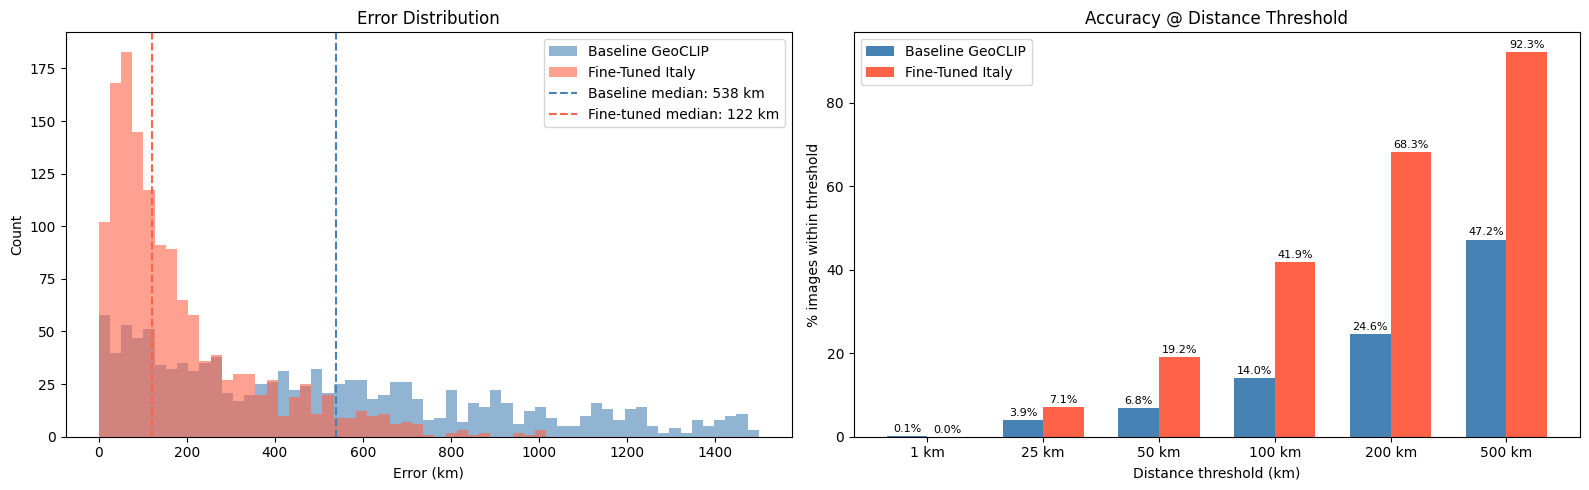

📊 Saved: comparison_error.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Error distribution histogram ---
ax = axes[0]
bins = np.linspace(0, 1500, 60)
ax.hist(baseline_df['error_km'],  bins=bins, alpha=0.6, label='Baseline GeoCLIP',   color='steelblue')
ax.hist(finetuned_df['error_km'], bins=bins, alpha=0.6, label='Fine-Tuned Italy',   color='tomato')
ax.axvline(baseline_df['error_km'].median(),  color='steelblue', linestyle='--', linewidth=1.5,
           label=f"Baseline median: {baseline_df['error_km'].median():.0f} km")
ax.axvline(finetuned_df['error_km'].median(), color='tomato',    linestyle='--', linewidth=1.5,
           label=f"Fine-tuned median: {finetuned_df['error_km'].median():.0f} km")
ax.set_xlabel("Error (km)")
ax.set_ylabel("Count")
ax.set_title("Error Distribution")
ax.legend()

# --- Right: Accuracy @ threshold bar chart ---
ax = axes[1]
thresholds = [1, 25, 50, 100, 200, 500]
b_acc = [np.mean(baseline_df['error_km']  <= t) * 100 for t in thresholds]
f_acc = [np.mean(finetuned_df['error_km'] <= t) * 100 for t in thresholds]

x = np.arange(len(thresholds))
w = 0.35
bars1 = ax.bar(x - w/2, b_acc, w, label='Baseline GeoCLIP', color='steelblue')
bars2 = ax.bar(x + w/2, f_acc, w, label='Fine-Tuned Italy',  color='tomato')
ax.set_xlabel("Distance threshold (km)")
ax.set_ylabel("% images within threshold")
ax.set_title("Accuracy @ Distance Threshold")
ax.set_xticks(x)
ax.set_xticklabels([f"{t} km" for t in thresholds])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("comparison_error.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: comparison_error.png")


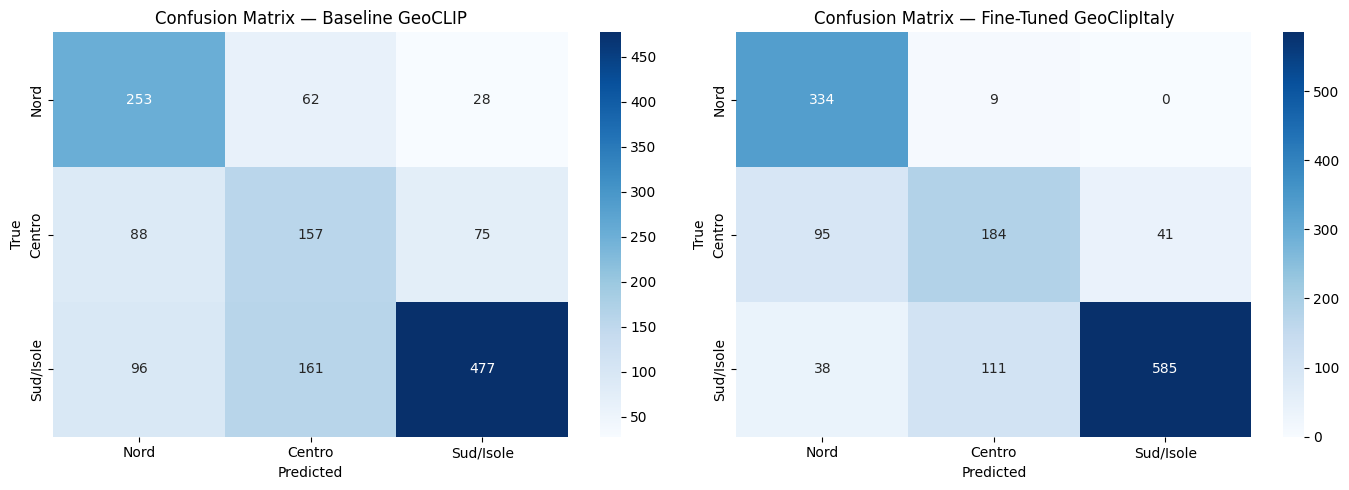


--- Baseline Classification Report ---
              precision    recall  f1-score   support

        Nord      0.579     0.738     0.649       343
      Centro      0.413     0.491     0.449       320
   Sud/Isole      0.822     0.650     0.726       734

    accuracy                          0.635      1397
   macro avg      0.605     0.626     0.608      1397
weighted avg      0.669     0.635     0.643      1397

--- Fine-Tuned Classification Report ---
              precision    recall  f1-score   support

        Nord      0.715     0.974     0.825       343
      Centro      0.605     0.575     0.590       320
   Sud/Isole      0.935     0.797     0.860       734

    accuracy                          0.790      1397
   macro avg      0.752     0.782     0.758      1397
weighted avg      0.805     0.790     0.790      1397



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def macro_region(lat):
    if lat > 44.0:   return "Nord"
    elif lat > 41.5: return "Centro"
    else:            return "Sud/Isole"

labels = ["Nord", "Centro", "Sud/Isole"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [
    (axes[0], baseline_df,  "Baseline GeoCLIP"),
    (axes[1], finetuned_df, "Fine-Tuned GeoClipItaly"),
]:
    true_r = [macro_region(r) for r in df['lat_true']]
    pred_r = [macro_region(r) for r in df['lat_pred']]
    cm = confusion_matrix(true_r, pred_r, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.savefig("comparison_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Baseline Classification Report ---")
print(classification_report(
    [macro_region(r) for r in baseline_df['lat_true']],
    [macro_region(r) for r in baseline_df['lat_pred']],
    labels=labels, digits=3
))
print("--- Fine-Tuned Classification Report ---")
print(classification_report(
    [macro_region(r) for r in finetuned_df['lat_true']],
    [macro_region(r) for r in finetuned_df['lat_pred']],
    labels=labels, digits=3
))


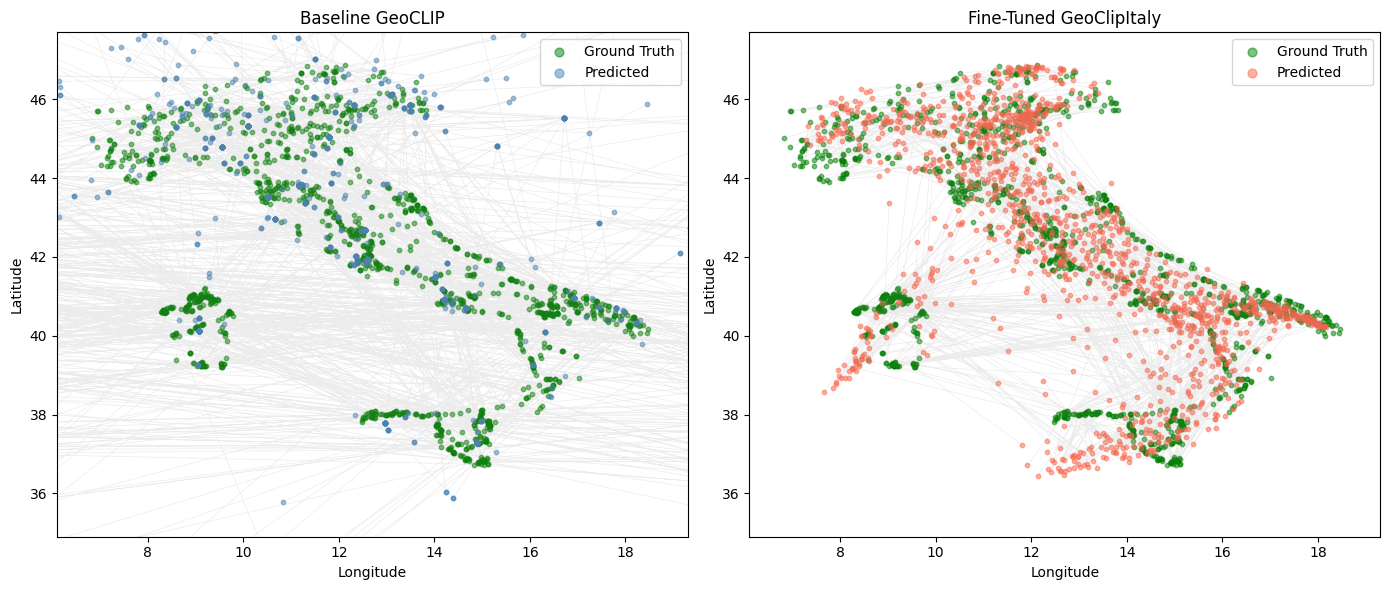

📊 Saved: comparison_scatter.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title, color in [
    (axes[0], baseline_df,  "Baseline GeoCLIP",       "steelblue"),
    (axes[1], finetuned_df, "Fine-Tuned GeoClipItaly", "tomato"),
]:
    ax.scatter(df['lon_true'], df['lat_true'], c='green',  s=10, alpha=0.5, label='Ground Truth')
    ax.scatter(df['lon_pred'], df['lat_pred'], c=color,    s=10, alpha=0.5, label='Predicted')

    # Draw lines between true and predicted (vectorized)
    lons = [x for pair in zip(df['lon_true'], df['lon_pred'], [None]*len(df)) for x in pair]
    lats = [x for pair in zip(df['lat_true'], df['lat_pred'], [None]*len(df)) for x in pair]
    ax.plot(lons, lats, c='gray', alpha=0.15, linewidth=0.5)

    # Italy bounding box
    ax.set_xlim(MIN_LON - 0.5, MAX_LON + 0.5)
    ax.set_ylim(MIN_LAT - 0.5, MAX_LAT + 0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("comparison_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: comparison_scatter.png")


## 🗺️ Section 6: Map Visualization

In [13]:
import folium
from IPython.display import display

# Show N random test images with both model predictions on the same map
N_MAP_SAMPLES = 10

merged = baseline_df.merge(
    finetuned_df[['path', 'lat_pred', 'lon_pred', 'error_km']],
    on='path', suffixes=('_base', '_ft')
).sample(n=min(N_MAP_SAMPLES, len(baseline_df)), random_state=42)

m = folium.Map(location=[42.5, 12.5], zoom_start=6)

for _, row in merged.iterrows():
    t_lat, t_lon = row['lat_true'], row['lon_true']
    b_lat, b_lon = row['lat_pred_base'], row['lon_pred_base']
    f_lat, f_lon = row['lat_pred_ft'],   row['lon_pred_ft']

    # Ground truth (green)
    folium.Marker([t_lat, t_lon],
                  popup=f"Ground Truth",
                  icon=folium.Icon(color='green', icon='home')).add_to(m)

    # Baseline prediction (blue)
    folium.Marker([b_lat, b_lon],
                  popup=f"Baseline: {row['error_km_base']:.0f} km",
                  icon=folium.Icon(color='blue', icon='info-sign')).add_to(m)

    # Fine-tuned prediction (red)
    folium.Marker([f_lat, f_lon],
                  popup=f"Fine-tuned: {row['error_km_ft']:.0f} km",
                  icon=folium.Icon(color='red', icon='star')).add_to(m)

    # Lines
    folium.PolyLine([(t_lat, t_lon), (b_lat, b_lon)],
                    color='blue', weight=1.5, opacity=0.6, dash_array='5').add_to(m)
    folium.PolyLine([(t_lat, t_lon), (f_lat, f_lon)],
                    color='red',  weight=1.5, opacity=0.6).add_to(m)

# Legend
legend = (
    "<div style='position:fixed;bottom:30px;left:30px;z-index:1000;"
    "background:white;padding:10px;border-radius:5px;"
    "border:1px solid grey;font-size:13px'>"
    "<b>Legend</b><br>"
    "&#x1F7E2; Ground Truth<br>"
    "&#x1F535; Baseline GeoCLIP (dashed)<br>"
    "&#x1F534; Fine-Tuned Italy (solid)"
    "</div>"
)
m.get_root().html.add_child(folium.Element(legend))
display(m)
m.save("comparison_map.html")
print("💾 Map saved: comparison_map.html")


💾 Map saved: comparison_map.html


## 🎲 Section 7: MC Dropout — Single Image Heatmap (Fine-Tuned Model)

In [14]:
import os
import folium
import numpy as np
import requests
import torch
from PIL import Image
from folium.plugins import HeatMap
from io import BytesIO
from IPython.display import display

# Pick a random test image from the extracted set — or replace with any local path
IMAGE_SOURCE = next(iter(image_index.values()))  # first available test image

def predict_mc_dropout(model, source, num_samples=50):
    if source.startswith("http"):
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(source, headers=headers, timeout=10)
        img = Image.open(BytesIO(r.content)).convert("RGB")
    elif os.path.exists(source):
        img = Image.open(source).convert("RGB")
    else:
        print(f"❌ Not found: {source}")
        return None

    tensor = eval_transform(img).unsqueeze(0).to(device)
    model.eval()
    enable_dropout(model)   # activate dropout only, BN stays frozen

    preds = []
    with torch.no_grad():
        for _ in range(num_samples):
            out = model(tensor).cpu().numpy()[0]
            lat, lon = denorm(out[0], out[1])
            preds.append([lat, lon])

    model.eval()
    return np.array(preds)


def create_heatmap(predictions, title="MC Dropout Heatmap"):
    coords = predictions.tolist()
    avg_lat = np.mean(predictions[:, 0])
    avg_lon = np.mean(predictions[:, 1])

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=6,
                   tiles="CartoDB dark_matter")

    weighted = [(lat, lon, 1.0 / len(coords)) for lat, lon in coords]
    magma = {
        '0.0': '#932667', '0.2': '#b5367a', '0.4': '#d3466b',
        '0.6': '#f1605d', '0.8': '#fd9668', '1.0': '#fcfdbf'
    }
    HeatMap(weighted, radius=25, blur=15, gradient=magma).add_to(m)

    folium.Marker([avg_lat, avg_lon],
                  popup=f"{title}<br>Lat: {avg_lat:.3f}, Lon: {avg_lon:.3f}",
                  icon=folium.Icon(color='orange', icon='star')).add_to(m)

    for lat, lon in coords:
        folium.CircleMarker([lat, lon], radius=2, color='cyan',
                            fill=True, fill_opacity=0.3).add_to(m)
    return m


print(f"🎲 Running {MC_DROPOUT_RUNS} MC Dropout passes on: {IMAGE_SOURCE}")
mc_preds = predict_mc_dropout(finetuned_model, IMAGE_SOURCE, num_samples=MC_DROPOUT_RUNS)

if mc_preds is not None:
    print(f"   Mean prediction : lat={np.mean(mc_preds[:,0]):.3f}, lon={np.mean(mc_preds[:,1]):.3f}")
    print(f"   Std             : lat={np.std(mc_preds[:,0]):.3f}, lon={np.std(mc_preds[:,1]):.3f}")
    hm = create_heatmap(mc_preds, title="Fine-Tuned Prediction")
    display(hm)
    hm.save("mc_dropout_heatmap.html")
    print("💾 Saved: mc_dropout_heatmap.html")


🎲 Running 50 MC Dropout passes on: /content/osv5m_images/train/18/300041331649998.jpg
   Mean prediction : lat=40.828, lon=16.951
   Std             : lat=0.137, lon=0.249


💾 Saved: mc_dropout_heatmap.html
